In [3]:
# unzip file
from zipfile import ZipFile

fileName = 'archive'

with ZipFile("demo_data/"+fileName+".zip", 'r') as zObject:
    zObject.extractall(
      path="demo_data/")

In [12]:
#!conda install opencv -y

In [1]:
import os
import cv2
import numpy as np

from matplotlib import pyplot as plt
from patchify import patchify
from PIL import Image
#import segmentation_models as sm
from tensorflow.keras.metrics import MeanIoU

from sklearn.preprocessing import MinMaxScaler, StandardScaler

os.environ["SM_FRAMEWORK"] = "tf.keras"

from tensorflow import keras
import segmentation_models as sm

"""
Use patchify....
Tile 1: 797 x 644 --> 768 x 512 --> 6
Tile 2: 509 x 544 --> 512 x 256 --> 2
Tile 3: 682 x 658 --> 512 x 512  --> 4
Tile 4: 1099 x 846 --> 1024 x 768 --> 12
Tile 5: 1126 x 1058 --> 1024 x 1024 --> 16
Tile 6: 859 x 838 --> 768 x 768 --> 9
Tile 7: 1817 x 2061 --> 1792 x 2048 --> 56
Tile 8: 2149 x 1479 --> 1280 x 2048 --> 40
Total 9 images in each folder * (145 patches) = 1305
Total 1305 patches of size 256x256
"""


scaler = MinMaxScaler()

#root_directory = 'demo_data/Semantic segmentation dataset/'
#root_directory = 'satData/S2B_MSIL2A_20230612T073619_N0509_R092_T37NCC_20230612T101141\.SAFE/GRANULE/L2A_T37NCC_A032722_20230612T075442/IMG_DATA/R10m/'
#root_directory = 'bands'

patch_size = 256

2023-07-04 14:01:20.127923: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-04 14:01:20.817569: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-04 14:01:20.819621: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-04 14:01:22.482417: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Segmentation Models: using `tf.keras` framework.


In [2]:
root_directory = 'sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/'
root_directory

'sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/'

In [3]:
#Read images from repsective 'images' subdirectory
#As all images are of ddifferent size we have 2 options, either resize or crop
#But, some images are too large and some small. Resizing will change the size of real objects.
#Therefore, we will crop them to a nearest size divisible by 256 and then 
#divide all images into patches of 256x256x3. 
image_dataset = []  
for path, subdirs, files in os.walk(root_directory):
    print(path)  
    dirname = path.split(os.path.sep)[-1]
    if dirname == 'test':   #Find all 'images' directories
        images = os.listdir(path)  #List of all image names in this subdirectory
        for i, image_name in enumerate(images):  
            if image_name.endswith(".jp2"):   #Only read jpg images...
               
                image = cv2.imread(path+"/"+image_name, 1)  #Read each image as BGR
                SIZE_X = (image.shape[1]//patch_size)*patch_size #Nearest size divisible by our patch size
                SIZE_Y = (image.shape[0]//patch_size)*patch_size #Nearest size divisible by our patch size
                image = Image.fromarray(image)
                image = image.crop((0 ,0, SIZE_X, SIZE_Y))  #Crop from top left corner
                #image = image.resize((SIZE_X, SIZE_Y))  #Try not to resize for semantic segmentation
                image = np.array(image)             
       
                #Extract patches from each image
                print("Now patchifying image:", path+"/"+image_name)
                patches_img = patchify(image, (patch_size, patch_size, 3), step=patch_size)  #Step=256 for 256 patches means no overlap
        
                for i in range(patches_img.shape[0]):
                    for j in range(patches_img.shape[1]):
                        
                        single_patch_img = patches_img[i,j,:,:]
                        
                        #Use minmaxscaler instead of just dividing by 255. 
                        single_patch_img = scaler.fit_transform(single_patch_img.reshape(-1, single_patch_img.shape[-1])).reshape(single_patch_img.shape)
                        
                        #single_patch_img = (single_patch_img.astype('float32')) / 255. 
                        single_patch_img = single_patch_img[0] #Drop the extra unecessary dimension that patchify adds.                               
                        image_dataset.append(single_patch_img)
                

sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/R10m
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/R20m
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/test


/opt/conda/lib/python3.11/site-packages/PIL/Image.py:3176: DecompressionBombWarning: Image size (115605504 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Now patchifying image: sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/test/T37NCC_20230627T073621_TCI_10m.jp2
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/.ipynb_checkpoints
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/R60m


In [4]:
#image_dataset

In [5]:
#Now do the same as above for masks
#For this specific dataset we could have added masks to the above code as masks have extension png
mask_dataset = []  
for path, subdirs, files in os.walk('/home/jovyan'):
    #print(path)  
    dirname = path.split(os.path.sep)[-1]
    if dirname == '_results':   #Find all 'images' directories
        masks = os.listdir(path)  #List of all image names in this subdirectory
        for i, mask_name in enumerate(masks):  
            if mask_name.endswith(".png"):   #Only read png images... (masks in this dataset)
               
                mask = cv2.imread(path+"/"+mask_name, 1)  #Read each image as Grey (or color but remember to map each color to an integer)
                mask = cv2.cvtColor(mask,cv2.COLOR_BGR2RGB)
                SIZE_X = (mask.shape[1]//patch_size)*patch_size #Nearest size divisible by our patch size
                SIZE_Y = (mask.shape[0]//patch_size)*patch_size #Nearest size divisible by our patch size
                mask = Image.fromarray(mask)
                mask = mask.crop((0 ,0, SIZE_X, SIZE_Y))  #Crop from top left corner
                #mask = mask.resize((SIZE_X, SIZE_Y))  #Try not to resize for semantic segmentation
                mask = np.array(mask)             
       
                #Extract patches from each image
                print("Now patchifying mask:", path+"/"+mask_name)
                patches_mask = patchify(mask, (patch_size, patch_size, 3), step=patch_size)  #Step=256 for 256 patches means no overlap
        
                for i in range(patches_mask.shape[0]):
                    for j in range(patches_mask.shape[1]):
                        
                        single_patch_mask = patches_mask[i,j,:,:]
                        #single_patch_img = (single_patch_img.astype('float32')) / 255. #No need to scale masks, but you can do it if you want
                        single_patch_mask = single_patch_mask[0] #Drop the extra unecessary dimension that patchify adds.                               
                        mask_dataset.append(single_patch_mask) 
 

/opt/conda/lib/python3.11/site-packages/PIL/Image.py:3176: DecompressionBombWarning: Image size (115605504 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Now patchifying mask: /home/jovyan/_results/20230627_unsupervised99_rgb.png


In [6]:
image_dataset = np.array(image_dataset)


In [7]:
mask_dataset =  np.array(mask_dataset)


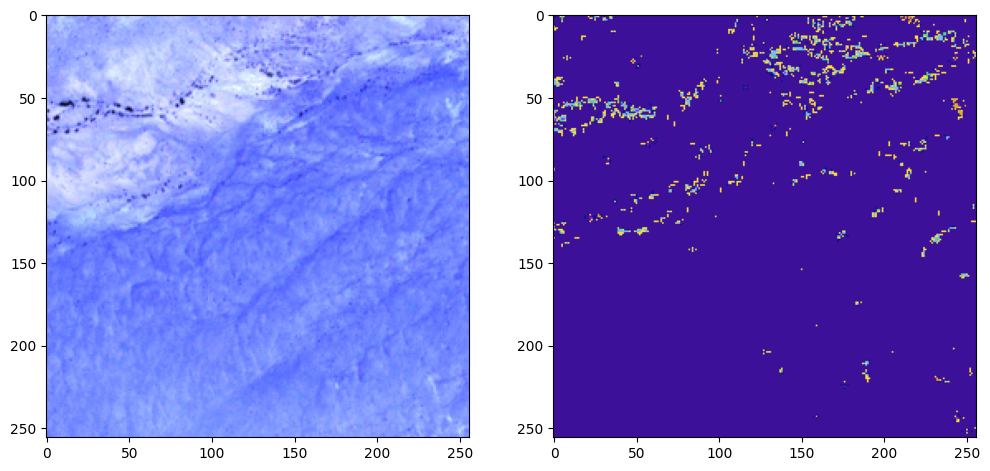

In [8]:
#Sanity check, view few mages
import random
import numpy as np
image_number = random.randint(0, len(image_dataset))
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(np.reshape(image_dataset[image_number], (patch_size, patch_size, 3)))
plt.subplot(122)
plt.imshow(np.reshape(mask_dataset[image_number], (patch_size, patch_size, 3)))
plt.show()

In [9]:
"""
RGB to HEX: (Hexadecimel --> base 16)
This number divided by sixteen (integer division; ignoring any remainder) gives 
the first hexadecimal digit (between 0 and F, where the letters A to F represent 
the numbers 10 to 15). The remainder gives the second hexadecimal digit. 
0-9 --> 0-9
10-15 --> A-F
Example: RGB --> R=201, G=, B=
R = 201/16 = 12 with remainder of 9. So hex code for R is C9 (remember C=12)
Calculating RGB from HEX: #3C1098
3C = 3*16 + 12 = 60
10 = 1*16 + 0 = 16
98 = 9*16 + 8 = 152
"""
## Convert HEX to RGB array
## Try the following to understand how python handles hex values...

#a=int('3C', 16)  #3C with base 16. Should return 60. 
#print(a)

##Do the same for all RGB channels in each hex code to convert to RGB
#Building = '#3C1098'.lstrip('#')
#Building = np.array(tuple(int(Building[i:i+2], 16) for i in (0, 2, 4))) # 60, 16, 152

#Land = '#8429F6'.lstrip('#')
#Land = np.array(tuple(int(Land[i:i+2], 16) for i in (0, 2, 4))) #132, 41, 246

#Road = '#6EC1E4'.lstrip('#') 
#Road = np.array(tuple(int(Road[i:i+2], 16) for i in (0, 2, 4))) #110, 193, 228

#Vegetation =  'FEDD3A'.lstrip('#') 
#Vegetation = np.array(tuple(int(Vegetation[i:i+2], 16) for i in (0, 2, 4))) #254, 221, 58

#Water = 'E2A929'.lstrip('#') 
#Water = np.array(tuple(int(Water[i:i+2], 16) for i in (0, 2, 4))) #226, 169, 41

#Unlabeled = '#9B9B9B'.lstrip('#') 
#Unlabeled = np.array(tuple(int(Unlabeled[i:i+2], 16) for i in (0, 2, 4))) #155, 155, 155


label1=np.array((254, 221, 58))
label2=np.array((110, 193, 228))
label3=np.array((60, 16, 152))
label4=np.array((132, 41, 246))

Building=np.array((60, 16, 152))
Land=np.array((126, 16, 152))
Road=np.array((244, 51, 171))
Vegetation=np.array((254, 221, 58))
Water=np.array((226, 169, 41))
Unlabeled=np.array((155, 155, 155))

In [10]:
label = single_patch_mask

# Now replace RGB to integer values to be used as labels.
#Find pixels with combination of RGB for the above defined arrays...
#if matches then replace all values in that pixel with a specific integer
def rgb_to_2D_label(label):
    """
    Suply our labale masks as input in RGB format. 
    Replace pixels with specific RGB values ...
    """
    label_seg = np.zeros(label.shape,dtype=np.uint8)
    label_seg [np.all(label==Building,axis=-1)] = 0
    label_seg [np.all(label==Land,axis=-1)] = 1
    label_seg [np.all(label==Road,axis=-1)] = 2
    label_seg [np.all(label==Vegetation,axis=-1)] = 3
    label_seg [np.all(label==Water,axis=-1)] = 4
    label_seg [np.all(label==Unlabeled,axis=-1)] = 5

    label_seg [np.all(label==label1,axis=-1)] = 6
    label_seg [np.all(label==label2,axis=-1)] = 7
    label_seg [np.all(label==label3,axis=-1)] = 8
    #label_seg [np.all(label==label4,axis=-1)] = 9
    
    label_seg = label_seg[:,:,0]  #Just take the first channel, no need for all 3 channels
    
    return label_seg

labels = []
for i in range(mask_dataset.shape[0]):
    label = rgb_to_2D_label(mask_dataset[i])
    labels.append(label)    

labels = np.array(labels)   
labels = np.expand_dims(labels, axis=3)
 

print("Unique labels in label dataset are: ", np.unique(labels))

Unique labels in label dataset are:  [0 1 2 4 5 6 7 8]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


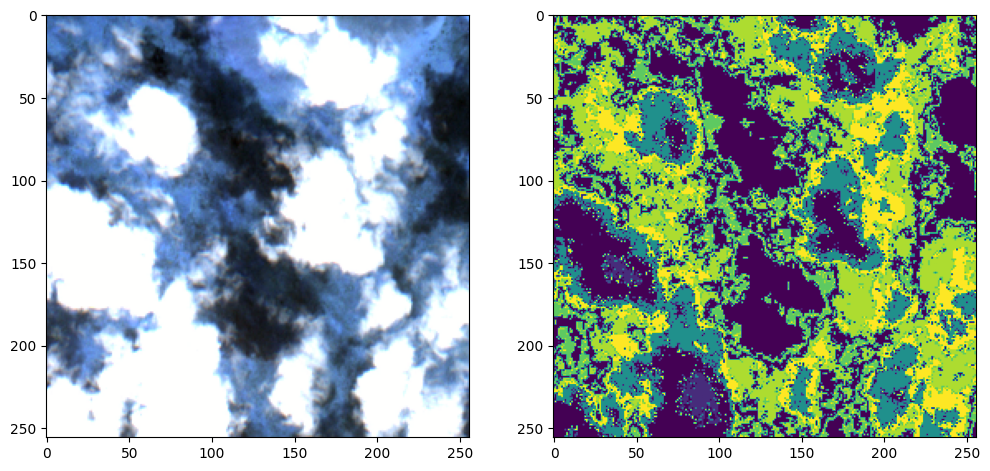

In [11]:
#Another Sanity check, view few images
import random
import numpy as np
image_number = random.randint(0, len(image_dataset))
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(image_dataset[image_number])
plt.subplot(122)
plt.imshow(labels[image_number][:,:,0])
plt.show()

In [12]:

#n_classes = len(np.unique(labels))
n_classes=10

from keras.utils import to_categorical
labels_cat = to_categorical(labels, num_classes=n_classes)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(image_dataset, labels_cat, test_size = 0.20, random_state = 42)


In [13]:

weights = [0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666]
dice_loss = sm.losses.DiceLoss(class_weights=weights) 
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)  #

In [14]:
IMG_HEIGHT = X_train.shape[1]
IMG_WIDTH  = X_train.shape[2]
IMG_CHANNELS = X_train.shape[3]

In [15]:
y_test

array([[[[0., 0., 0., ..., 0., 0., 0.],
         [1., 0., 0., ..., 0., 0., 0.],
         [1., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 1., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [1., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 1., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 1., 0.],
         [0., 0., 0., ..., 0., 1., 0.]],

        ...,

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
    

In [16]:
from simple_multi_unet_model import multi_unet_model, jacard_coef  

metrics=['accuracy', jacard_coef]

def get_model():
    return multi_unet_model(n_classes=n_classes, IMG_HEIGHT=IMG_HEIGHT, IMG_WIDTH=IMG_WIDTH, IMG_CHANNELS=IMG_CHANNELS)

model = get_model()
#model.compile(optimizer='adam', loss=total_loss, metrics=metrics)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)
model.summary()


history1 = model.fit(X_train, y_train, 
                    batch_size = 16, 
                    verbose=1, 
                    epochs=10, 
                    validation_data=(X_test, y_test), 
                    shuffle=False)

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 16  448         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 256, 256, 16  0           ['conv2d[0][0]']                 
                                )                                                             

2023-07-04 14:02:53.400856: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1109655552 exceeds 10% of free system memory.
2023-07-04 14:02:54.019713: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 3698851840 exceeds 10% of free system memory.


Epoch 1/10
89/89 [==============================] - ETA: 0s - loss: 1.8011 - accuracy: 0.2862 - jacard_coef: 0.1120

2023-07-04 14:08:26.487284: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 925368320 exceeds 10% of free system memory.


89/89 [==============================] - 345s 4s/step - loss: 1.8011 - accuracy: 0.2862 - jacard_coef: 0.1120 - val_loss: 1.4099 - val_accuracy: 0.3953 - val_jacard_coef: 0.1730
Epoch 2/10
89/89 [==============================] - 340s 4s/step - loss: 1.4092 - accuracy: 0.4017 - jacard_coef: 0.1789 - val_loss: 1.2878 - val_accuracy: 0.4700 - val_jacard_coef: 0.1950
Epoch 3/10
89/89 [==============================] - 343s 4s/step - loss: 1.3339 - accuracy: 0.4436 - jacard_coef: 0.1971 - val_loss: 1.2481 - val_accuracy: 0.4975 - val_jacard_coef: 0.2068
Epoch 4/10
89/89 [==============================] - 341s 4s/step - loss: 1.3084 - accuracy: 0.4588 - jacard_coef: 0.2038 - val_loss: 1.2585 - val_accuracy: 0.4873 - val_jacard_coef: 0.2039
Epoch 5/10
89/89 [==============================] - 339s 4s/step - loss: 1.2892 - accuracy: 0.4703 - jacard_coef: 0.2088 - val_loss: 1.2888 - val_accuracy: 0.4595 - val_jacard_coef: 0.1943
Epoch 6/10
89/89 [==============================] - 340s 4s/step -

In [22]:
#Minmaxscaler
#With weights...[0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666]   in Dice loss
#With focal loss only, after 100 epochs val jacard is: 0.62  (Mean IoU: 0.6)            
#With dice loss only, after 100 epochs val jacard is: 0.74 (Reached 0.7 in 40 epochs)
#With dice + 5 focal, after 100 epochs val jacard is: 0.711 (Mean IoU: 0.611)
##With dice + 1 focal, after 100 epochs val jacard is: 0.75 (Mean IoU: 0.62)
#Using categorical crossentropy as loss: 0.71

##With calculated weights in Dice loss.    
#With dice loss only, after 100 epochs val jacard is: 0.672 (0.52 iou)


##Standardscaler 
#Using categorical crossentropy as loss: 0.677

model.save('models/satellite_standard_unet_100epochs.hdf5')

In [ ]:
############################################################
#TRY ANOTHE MODEL - WITH PRETRINED WEIGHTS
#Resnet backbone
BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

# preprocess input
X_train_prepr = preprocess_input(X_train)
X_test_prepr = preprocess_input(X_test)

# define model
model_resnet_backbone = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=n_classes, activation='softmax')

# compile keras model with defined optimozer, loss and metrics
#model_resnet_backbone.compile(optimizer='adam', loss=focal_loss, metrics=metrics)
model_resnet_backbone.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)

print(model_resnet_backbone.summary())

In [18]:
history2=model_resnet_backbone.fit(X_train_prepr, 
          y_train,
          batch_size=16, 
          epochs=10,
          verbose=1,
          validation_data=(X_test_prepr, y_test))


2023-07-04 14:59:43.434244: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1109655552 exceeds 10% of free system memory.
2023-07-04 14:59:44.199093: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 3698851840 exceeds 10% of free system memory.


Epoch 1/100
89/89 [==============================] - 664s 7s/step - loss: 1.4753 - accuracy: 0.4185 - jacard_coef: 0.1696 - val_loss: 692.4395 - val_accuracy: 0.2120 - val_jacard_coef: 0.1189
Epoch 2/100
89/89 [==============================] - 610s 7s/step - loss: 1.2944 - accuracy: 0.4768 - jacard_coef: 0.2078 - val_loss: 270.6745 - val_accuracy: 0.2905 - val_jacard_coef: 0.1663
Epoch 3/100
89/89 [==============================] - 611s 7s/step - loss: 1.2835 - accuracy: 0.4834 - jacard_coef: 0.2131 - val_loss: 546.9875 - val_accuracy: 0.2911 - val_jacard_coef: 0.1649
Epoch 4/100
89/89 [==============================] - 611s 7s/step - loss: 1.2544 - accuracy: 0.4974 - jacard_coef: 0.2216 - val_loss: 522.1511 - val_accuracy: 0.2913 - val_jacard_coef: 0.1660
Epoch 5/100
89/89 [==============================] - 612s 7s/step - loss: 1.2364 - accuracy: 0.5084 - jacard_coef: 0.2282 - val_loss: 12.3532 - val_accuracy: 0.2923 - val_jacard_coef: 0.1539
Epoch 6/100
89/89 [======================

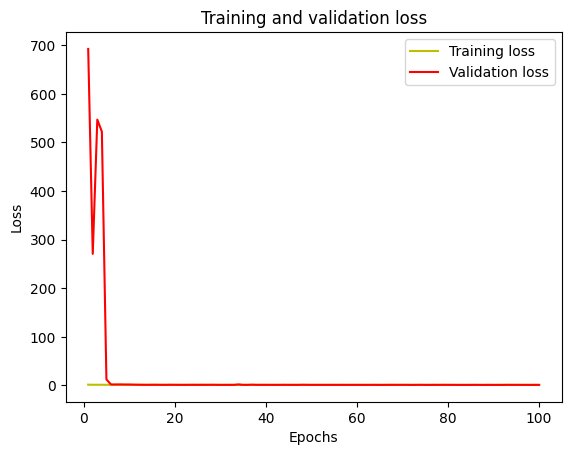

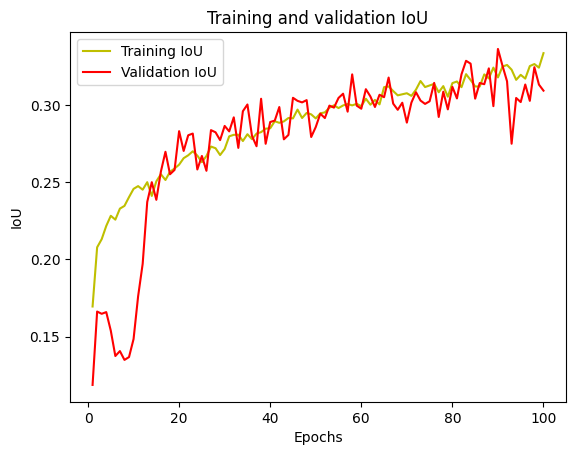

In [20]:
#plot the training and validation accuracy and loss at each epoch
history = history2
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['jacard_coef']
val_acc = history.history['val_jacard_coef']

plt.plot(epochs, acc, 'y', label='Training IoU')
plt.plot(epochs, val_acc, 'r', label='Validation IoU')
plt.title('Training and validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

In [24]:
##################################
from keras.models import load_model
model = load_model("models/satellite_standard_unet_100epochs.hdf5",
                   custom_objects={'dice_loss_plus_2focal_loss': total_loss,
                                   'jacard_coef':jacard_coef})

#IOU
y_pred=model.predict(X_test)
y_pred_argmax=np.argmax(y_pred, axis=3)
y_test_argmax=np.argmax(y_test, axis=3)


#Using built in keras function for IoU
from keras.metrics import MeanIoU
n_classes = 10
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(y_test_argmax, y_pred_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

12/12 [==============================] - 16s 1s/step
Mean IoU = 0.22809865


1/1 [==============================] - 0s 61ms/step


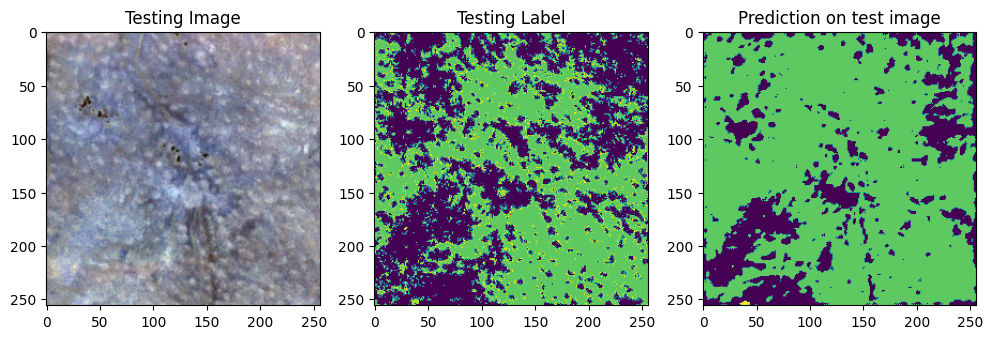

In [33]:
#Predict on a few images

import random
test_img_number = random.randint(0, len(X_test))
test_img = X_test[test_img_number]
ground_truth=y_test_argmax[test_img_number]
#test_img_norm=test_img[:,:,0][:,:,None]
test_img_input=np.expand_dims(test_img, 0)
prediction = (model.predict(test_img_input))
predicted_img=np.argmax(prediction, axis=3)[0,:,:]


plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img)
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth)
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(predicted_img)
plt.show()


In [47]:
#test area
n_classes = len(np.unique(labels))
n_classes

8

In [18]:
history1